# 02 — Preprocessing Pipeline

**Mục tiêu notebook này:**
1. Chạy `preprocess.py` để tạo ra `X_train/val/test.npy` và `y_train/val/test.npy`
2. Verify shape, dtype, range của output
3. Visualize phân bố class (class distribution)
4. Debug từng bước pipeline trên 1 file thực tế
5. Kiểm tra `process_realtime_window` — đường inference production

**Yêu cầu:** Dataset GaitPDB tại `ml/data/raw/gaitpdb/`
**Thời gian ước tính:** 2–5 phút

## 0. Setup & Import

In [9]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# Chạy từ thư mục gốc Smart Insole/
# Nếu chạy từ ml/notebooks/ thì đổi: ROOT = Path('../../')
ROOT = Path('../../')
ML_SRC = ROOT / 'ml' / 'src'
if str(ML_SRC) not in sys.path:
    sys.path.insert(0, str(ML_SRC))

PROCESSED_DIR = ROOT / 'ml' / 'data' / 'processed'
RAW_GAITPDB   = ROOT / 'ml' / 'data' / 'raw' / 'gaitpdb'
RAW_GAITNDD   = ROOT / 'ml' / 'data' / 'raw' / 'gaitndd'

print(f'ROOT          : {ROOT.resolve()}')
print(f'GaitPDB exists: {RAW_GAITPDB.exists()}')
print(f'GaitNDD exists: {RAW_GAITNDD.exists()}')
print(f'processed dir : {PROCESSED_DIR.exists()}')

ROOT          : D:\CODE\Smart Insole
GaitPDB exists: True
GaitNDD exists: False
processed dir : True


## 1. Chạy Preprocessing Pipeline

Cell dưới import và gọi trực tiếp `main()` từ `preprocess.py`.

> **Chạy từ terminal thay thế:**
> ```bash
> python ml/src/preprocess.py
> ```

In [10]:
import importlib
import preprocess
importlib.reload(preprocess)

# Override đường dẫn
preprocess.RAW_GAITPDB   = RAW_GAITPDB
preprocess.RAW_GAITNDD   = RAW_GAITNDD
preprocess.PROCESSED_DIR = PROCESSED_DIR

preprocess.main()

10:50:16 [INFO] === Smart Insole Preprocessing Pipeline ===
10:50:16 [INFO] Window: 100 steps | Stride: 50 | Target: 50Hz | Lowpass: 20Hz
10:50:16 [INFO] --- Load GaitPDB ---
10:50:16 [INFO] GaitPDB — tìm thấy 214 PD files, 92 Control files
10:51:01 [INFO] GaitPDB: 32773 windows, shape (32773, 100, 4)
10:51:01 [INFO] --- Load GaitNDD ---
10:51:01 [ERROR] Không tìm thấy thư mục GaitNDD: ..\..\ml\data\raw\gaitndd
10:51:01 [INFO] GaitNDD: 0 windows, shape (0, 100, 4)
10:51:01 [INFO] --- Tổng hợp ---
10:51:01 [INFO] Total: 32773 windows | Shape X: (32773, 100, 4) | Shape y: (32773,)
10:51:01 [INFO]   Label 0 (Normal): 10011 windows (30.5%)
10:51:01 [INFO]   Label 1 (Parkinson): 22762 windows (69.5%)
10:51:01 [INFO] --- Split và lưu ---
10:51:01 [INFO] Saved X_train.npy — shape (22941, 100, 4)
10:51:01 [INFO] Saved y_train.npy — shape (22941,)
10:51:01 [INFO] Saved X_val.npy — shape (4916, 100, 4)
10:51:01 [INFO] Saved y_val.npy — shape (4916,)
10:51:01 [INFO] Saved X_test.npy — shape (4916

## 2. Load Output & Verify Shape / Range

- **Shape** phải là `(N, 100, 4)` cho X và `(N,)` cho y
- **dtype** phải là `float32` / `int8`
- **Range** phải nằm trong `[0, 1]` sau normalize

In [11]:
splits = {}
for name in ['X_train','y_train','X_val','y_val','X_test','y_test']:
    path = PROCESSED_DIR / f'{name}.npy'
    if path.exists():
        splits[name] = np.load(path)
    else:
        print(f'Missing: {path}')

CLASS_NAMES = ['Normal', 'Parkinson', 'Abnormal']

print(f"{'Tên':<12} {'Shape':<20} {'dtype':<10} {'Min':>8} {'Max':>8}")
print('-' * 62)
for name, arr in splits.items():
    if 'X' in name:
        print(f"{name:<12} {str(arr.shape):<20} {str(arr.dtype):<10} {arr.min():8.4f} {arr.max():8.4f}")
    else:
        unique, counts = np.unique(arr, return_counts=True)
        dist = {CLASS_NAMES[int(u)]: int(c) for u, c in zip(unique, counts)}
        print(f"{name:<12} {str(arr.shape):<20} {str(arr.dtype):<10}  {dist}")

# Assertions
assert splits['X_train'].ndim == 3
assert splits['X_train'].shape[1] == 100
assert splits['X_train'].shape[2] == 4
assert splits['X_train'].dtype == np.float32
assert splits['X_train'].min() >= -0.01
assert splits['X_train'].max() <= 1.01
assert len(splits['X_train']) == len(splits['y_train'])
print('\n✅ Tất cả assertions PASSED')

Tên          Shape                dtype           Min      Max
--------------------------------------------------------------
X_train      (22941, 100, 4)      float32      0.0000   1.0000
y_train      (22941,)             int8        {'Normal': 7008, 'Parkinson': 15933}
X_val        (4916, 100, 4)       float32      0.0000   1.0000
y_val        (4916,)              int8        {'Normal': 1501, 'Parkinson': 3415}
X_test       (4916, 100, 4)       float32      0.0000   1.0000
y_test       (4916,)              int8        {'Normal': 1502, 'Parkinson': 3414}

✅ Tất cả assertions PASSED


## 3. Phân bố Class (Class Distribution)

Kiểm tra imbalance — `train.py` sẽ dùng `class_weight='balanced'` để xử lý.

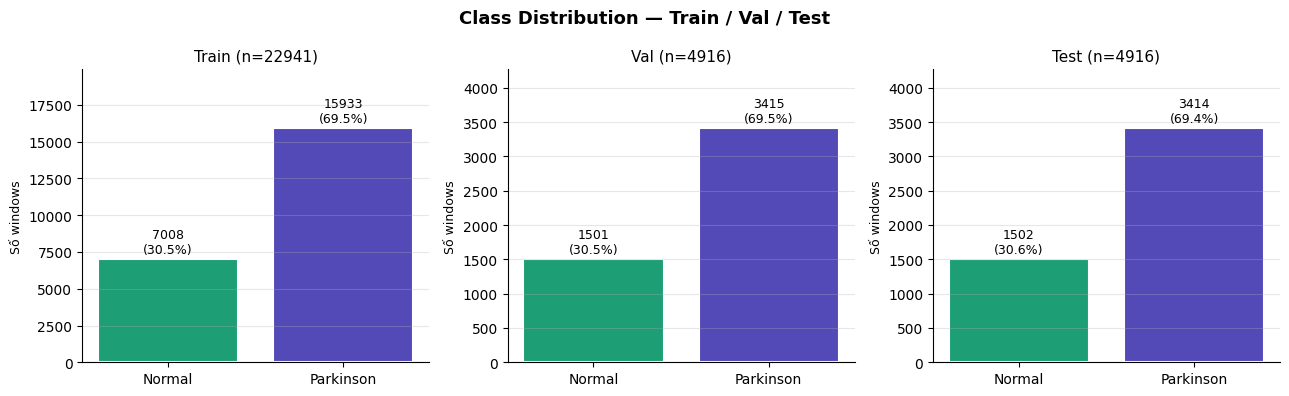


Class weights sẽ dùng trong train.py:
  Normal      : 1.6368
  Parkinson   : 0.7199


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Class Distribution — Train / Val / Test', fontsize=13, fontweight='bold')
COLORS = ['#1D9E75', '#534AB7', '#D85A30']

for ax, split_name in zip(axes, ['train', 'val', 'test']):
    y = splits[f'y_{split_name}']
    unique, counts = np.unique(y, return_counts=True)
    labels = [CLASS_NAMES[int(u)] for u in unique]
    colors = [COLORS[int(u)] for u in unique]
    bars = ax.bar(labels, counts, color=colors, edgecolor='white', linewidth=1.5)
    total = counts.sum()
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                f'{cnt}\n({100*cnt/total:.1f}%)', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'{split_name.capitalize()} (n={total})', fontsize=11)
    ax.set_ylabel('Số windows', fontsize=9)
    ax.set_ylim(0, counts.max() * 1.25)
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'class_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

from sklearn.utils.class_weight import compute_class_weight
y_train = splits['y_train']
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
print('\nClass weights sẽ dùng trong train.py:')
for name, w in zip(CLASS_NAMES[:len(cw)], cw):
    print(f'  {name:<12}: {w:.4f}')

## 4. Visualize Sample Windows

Chọn ngẫu nhiên 1 window mỗi class và vẽ 4 kênh sensor.
Tín hiệu phải trông như gait waveform (lực thay đổi theo chu kỳ bước chân).

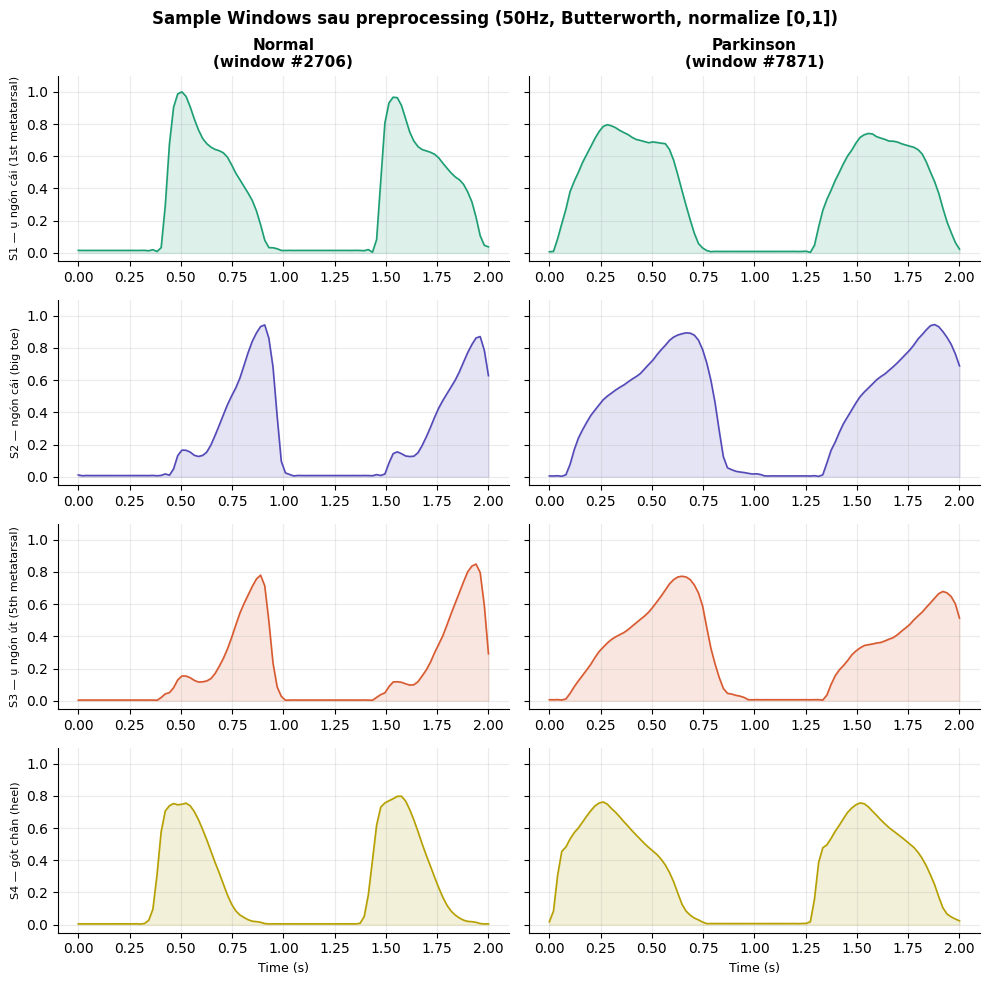

Lưu: ml/data/processed/sample_windows.png


In [13]:
np.random.seed(42)
X_train = splits['X_train']
y_train = splits['y_train']

SENSOR_LABELS = [
    'S1 — ụ ngón cái (1st metatarsal)',
    'S2 — ngón cái (big toe)',
    'S3 — ụ ngón út (5th metatarsal)',
    'S4 — gót chân (heel)'
]
SENSOR_COLORS = ['#1D9E75', '#534AB7', '#D85A30', '#B5A000']
time_axis = np.linspace(0, 2.0, 100)  # 2 giây @ 50Hz

available_classes = np.unique(y_train)
n_cls = len(available_classes)

fig, axes = plt.subplots(4, n_cls, figsize=(5*n_cls, 10), sharey='row')
if n_cls == 1: axes = axes.reshape(4,1)
fig.suptitle('Sample Windows sau preprocessing (50Hz, Butterworth, normalize [0,1])',
             fontsize=12, fontweight='bold')

for col, cls_idx in enumerate(available_classes):
    mask = np.where(y_train == cls_idx)[0]
    chosen = np.random.choice(mask)
    window = X_train[chosen]
    axes[0][col].set_title(f'{CLASS_NAMES[cls_idx]}\n(window #{chosen})', fontsize=11, fontweight='bold')
    for row, (label, color) in enumerate(zip(SENSOR_LABELS, SENSOR_COLORS)):
        ax = axes[row][col]
        ax.plot(time_axis, window[:, row], color=color, linewidth=1.2)
        ax.fill_between(time_axis, 0, window[:, row], alpha=0.15, color=color)
        ax.set_ylim(-0.05, 1.1)
        ax.set_ylabel(label if col == 0 else '', fontsize=8)
        ax.grid(alpha=0.25)
        ax.spines[['top','right']].set_visible(False)

for ax in axes[-1]: ax.set_xlabel('Time (s)', fontsize=9)

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'sample_windows.png', dpi=130, bbox_inches='tight')
plt.show()
print('Lưu: ml/data/processed/sample_windows.png')

## 5. Debug Pipeline Từng Bước trên 1 File

Trace các bước transform trên 1 file cụ thể để xác nhận không có bug:
`aggregate → filter → normalize → downsample → sliding window`

In [14]:
from preprocess import (
    aggregate_gaitpdb_columns, apply_filter_to_array,
    normalize_per_subject, downsample_to_target, sliding_window,
    WINDOW_SIZE, STRIDE, LOWPASS_CUTOFF, ORIGINAL_HZ, TARGET_HZ,
)

pd_files = sorted(RAW_GAITPDB.glob('*Pt*.txt'))

if not pd_files:
    print('Không tìm thấy file GaitPDB.')
else:
    f = pd_files[0]
    print(f'File: {f.name}')
    df = pd.read_csv(f, sep='\t', header=None, engine='python').dropna()
    print(f'\n[0] Raw CSV          : shape={df.shape}')

    s1 = aggregate_gaitpdb_columns(df)
    print(f'[1] Aggregate → 4ch  : shape={s1.shape}, range=[{s1.min():.1f}, {s1.max():.1f}] N')

    s2 = apply_filter_to_array(s1, LOWPASS_CUTOFF, ORIGINAL_HZ)
    print(f'[2] Lowpass {LOWPASS_CUTOFF}Hz     : shape={s2.shape}, range=[{s2.min():.1f}, {s2.max():.1f}] N')

    s3 = normalize_per_subject(s2)
    print(f'[3] Normalize [0,1]  : shape={s3.shape}, range=[{s3.min():.4f}, {s3.max():.4f}]')

    s4 = downsample_to_target(s3, ORIGINAL_HZ, TARGET_HZ)
    print(f'[4] Downsample 50Hz  : shape={s4.shape}  ({ORIGINAL_HZ}→{TARGET_HZ} Hz, factor=2)')

    s5 = sliding_window(s4, WINDOW_SIZE, STRIDE)
    print(f'[5] Sliding window   : shape={s5.shape}  (window={WINDOW_SIZE}, stride={STRIDE})')
    expected = (s4.shape[0] - WINDOW_SIZE) // STRIDE + 1
    print(f'   Expected windows  : {expected} — actual: {s5.shape[0]}')
    print('\n✅ Pipeline OK' if s5.shape[0] == expected else f'\n⚠ Mismatch: expected {expected} got {s5.shape[0]}')

File: GaPt03_01.txt

[0] Raw CSV          : shape=(12119, 19)
[1] Aggregate → 4ch  : shape=(12119, 4), range=[0.0, 223.3] N
[2] Lowpass 20.0Hz     : shape=(12119, 4), range=[-2.7, 223.4] N
[3] Normalize [0,1]  : shape=(12119, 4), range=[0.0000, 1.0000]
[4] Downsample 50Hz  : shape=(6060, 4)  (100→50 Hz, factor=2)
[5] Sliding window   : shape=(120, 100, 4)  (window=100, stride=50)
   Expected windows  : 120 — actual: 120

✅ Pipeline OK


## 6. Kiểm tra `process_realtime_window` (Production Inference Path)

Hàm này được gọi ở backend khi BLE gửi data vào.  
Verify output shape `(1, 100, 4)` và range `[0, 1]`.

In [15]:
from preprocess import process_realtime_window

np.random.seed(0)
# Simulate ADC thô từ ESP32 + ADS1115
# S1 GPIO4 (12-bit): 0-4095 | S2 ADS1115: 0~26400 | S3 GPIO2: 0-4095 | S4 GPIO3: 0-4095
raw_mock = np.column_stack([
    np.random.uniform(0, 3000, 100).astype(np.float32),
    np.random.uniform(0, 20000, 100).astype(np.float32),
    np.random.uniform(0, 1500, 100).astype(np.float32),
    np.random.uniform(500, 4000, 100).astype(np.float32),
])

print('Input (raw ADC):')
for i, (name, maxval) in enumerate([('S1 GPIO4',4095),('S2 ADS1115',26400),('S3 GPIO2',4095),('S4 GPIO3',4095)]):
    print(f'  {name}: [{raw_mock[:,i].min():.0f}, {raw_mock[:,i].max():.0f}]  (max={maxval})')

out = process_realtime_window(raw_mock)

print(f'\nOutput: shape={out.shape}, dtype={out.dtype}')
print(f'  Range: [{out.min():.4f}, {out.max():.4f}]')

assert out.shape == (1, 100, 4), 'Shape sai!'
assert out.min() >= -0.01 and out.max() <= 1.01, 'Range ngoai [0,1]!'
print('\n✅ process_realtime_window OK — sẵn sàng cho InferenceEngine.predict()')

Input (raw ADC):
  S1 GPIO4: [14, 2965]  (max=4095)
  S2 ADS1115: [234, 19977]  (max=26400)
  S3 GPIO2: [20, 1486]  (max=4095)
  S4 GPIO3: [540, 3858]  (max=4095)

Output: shape=(1, 100, 4), dtype=float32
  Range: [0.0000, 1.0000]

✅ process_realtime_window OK — sẵn sàng cho InferenceEngine.predict()


## 7. Tóm tắt

### Files đã tạo:
```
ml/data/processed/
├── X_train.npy, y_train.npy
├── X_val.npy,   y_val.npy
├── X_test.npy,  y_test.npy
├── class_distribution.png
└── sample_windows.png
ml/models/
└── label_encoder.pkl
```

### Bước tiếp theo:
→ **`03_train_model.ipynb`** — Train LSTM + learning curve

In [16]:
total = sum(splits[f'y_{s}'].shape[0] for s in ['train','val','test'])
print('=' * 50)
print('  PREPROCESSING HOÀN TẤT')
print('=' * 50)
print(f"  Tổng windows  : {total:,}")
print(f"  Train         : {splits['y_train'].shape[0]:,}")
print(f"  Val           : {splits['y_val'].shape[0]:,}")
print(f"  Test          : {splits['y_test'].shape[0]:,}")
print(f"  Window shape  : (100, 4)  — 2s @ 50Hz × 4 sensors")
print(f"  Output dir    : {PROCESSED_DIR.resolve()}")
print('=' * 50)
print('  → Tiếp theo: 03_train_model.ipynb')

  PREPROCESSING HOÀN TẤT
  Tổng windows  : 32,773
  Train         : 22,941
  Val           : 4,916
  Test          : 4,916
  Window shape  : (100, 4)  — 2s @ 50Hz × 4 sensors
  Output dir    : D:\CODE\Smart Insole\ml\data\processed
  → Tiếp theo: 03_train_model.ipynb
